# 01 - M5 Raw-Data Audit and Initial Exploratory Analysis

## Why this notebook is needed

Forecasting and inventory conclusions are only credible when the source data are understood and validated first. This notebook checks whether the M5 files are complete, structurally consistent, and suitable for later product-store analysis. It also provides a small amount of initial exploratory evidence about sales variability and zero-sales behavior.

## Notebook objectives

1. Download the official Kaggle files when needed and confirm that they are valid.
2. Record the shape and structure of each file.
3. Check identifiers, dates, sales values, prices, and expected unique keys.
4. Confirm that the planned sales-calendar-price joins are structurally possible.
5. Describe what the audit results mean for the next stage of the project.

This notebook performs validation and initial EDA only. It does not yet select product-store series, fit forecasting models, or simulate inventory policies.

## Important interpretation limitation

M5 contains recorded unit sales. A value of zero means that no sale was recorded on that day; it does not prove that customer demand was zero. An item could have been unavailable, not yet offered, or otherwise unable to record a sale. Consequently, this project will describe observed sales patterns and simulated inventory outcomes rather than claim to observe Walmart's true unmet demand or actual stockouts.

## 1. Imports and project paths

The imports provide table processing, numerical calculations, and plotting. Project-relative paths are used so that the notebook does not depend on one student's personal computer path.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

# This works when Jupyter starts from either the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw-data directory: {RAW_DATA_DIR}")

Project root: /Users/sumitchaurasia/Desktop/USD/FinalProj/module_one_project
Raw-data directory: /Users/sumitchaurasia/Desktop/USD/FinalProj/module_one_project/data/raw


## 2. Kaggle download and required-file check

The project uses the official [M5 Forecasting - Accuracy](https://www.kaggle.com/competitions/m5-forecasting-accuracy/data) competition files. The helper checks all five local files and downloads them from Kaggle only when they are missing or invalid. Kaggle authentication and acceptance of the competition rules are required for a first-time download. Checksums protect the analysis from silently using incomplete or corrupted files.

In [2]:
import sys

# Make the repository's scripts package importable when the notebook starts in notebooks/.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.download_data import REQUIRED_FILE_HASHES, ensure_m5_data

ensure_m5_data(RAW_DATA_DIR)
required_files = list(REQUIRED_FILE_HASHES)

file_check = pd.DataFrame(
    {
        "file": required_files,
        "exists": [(RAW_DATA_DIR / name).exists() for name in required_files],
        "size_mb": [
            round((RAW_DATA_DIR / name).stat().st_size / (1024**2), 2)
            if (RAW_DATA_DIR / name).exists()
            else 0
            for name in required_files
        ],
    }
)
display(file_check)

assert file_check["exists"].all(), "One or more required M5 files are missing."
assert (file_check["size_mb"] > 0).all(), "One or more required M5 files are empty."

All five M5 files are present and their checksums are valid.


,file,exists,size_mb
0,calendar.csv,True,0.10
1,sales_train_evaluation.csv,True,116.10
2,sales_train_validation.csv,True,114.45
3,sample_submission.csv,True,4.99
4,sell_prices.csv,True,193.97


### Inference

All five required M5 files are present, non-empty, and checksum-verified. The sales and price files are much larger than the calendar and submission files, so memory-conscious data types are appropriate when loading them. The download check establishes file integrity; the remaining sections evaluate the analytical contents.

## 3. Load the M5 files

The sales files contain almost 2,000 daily columns, and the price file contains more than 6 million rows. Smaller numerical types and categorical identifier types reduce memory use without changing the recorded values. The evaluation file will be the primary sales history because it extends through `d_1941`; the validation file is loaded for structural comparison.

In [3]:
calendar = pd.read_csv(RAW_DATA_DIR / "calendar.csv", parse_dates=["date"])
sample_submission = pd.read_csv(RAW_DATA_DIR / "sample_submission.csv")

print(f"Calendar shape: {calendar.shape}")
print(f"Sample-submission shape: {sample_submission.shape}")
display(calendar.head())

Calendar shape: (1969, 14)
Sample-submission shape: (60980, 29)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [4]:
# Read only the header first so the daily column names can be assigned a smaller integer type.
evaluation_header = pd.read_csv(RAW_DATA_DIR / "sales_train_evaluation.csv", nrows=0)
evaluation_day_columns = [name for name in evaluation_header.columns if name.startswith("d_")]

identifier_columns = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
sales_dtypes = {name: "int16" for name in evaluation_day_columns}
sales_dtypes.update({name: "category" for name in identifier_columns})

sales_evaluation = pd.read_csv(
    RAW_DATA_DIR / "sales_train_evaluation.csv",
    dtype=sales_dtypes,
)

selected_preview_columns = identifier_columns + evaluation_day_columns[:3]
print(f"Evaluation-sales shape: {sales_evaluation.shape}")
display(sales_evaluation[selected_preview_columns].head())

Evaluation-sales shape: (30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0


In [5]:
validation_header = pd.read_csv(RAW_DATA_DIR / "sales_train_validation.csv", nrows=0)
validation_day_columns = [name for name in validation_header.columns if name.startswith("d_")]
validation_dtypes = {name: "int16" for name in validation_day_columns}
validation_dtypes.update({name: "category" for name in identifier_columns})

sales_validation = pd.read_csv(
    RAW_DATA_DIR / "sales_train_validation.csv",
    dtype=validation_dtypes,
)

price_dtypes = {
    "store_id": "category",
    "item_id": "category",
    "wm_yr_wk": "int32",
    "sell_price": "float32",
}
sell_prices = pd.read_csv(RAW_DATA_DIR / "sell_prices.csv", dtype=price_dtypes)

print(f"Validation-sales shape: {sales_validation.shape}")
print(f"Selling-price shape: {sell_prices.shape}")
display(sell_prices.head())

Validation-sales shape: (30490, 1919)
Selling-price shape: (6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


## 4. Sales-file audit

The following checks establish the basic analytical unit and assess whether recorded sales contain structurally invalid values.

- **Unique identifiers:** confirm the number of products, stores, categories, departments, and states represented.
- **Duplicate series IDs:** a duplicate would mean that one product-store series appears more than once.
- **Negative sales:** recorded unit sales should not be negative in this dataset.
- **Zero-sales share:** measures how often no sale was recorded and indicates how intermittent the series may be. It is not proof of zero customer demand.

In [6]:
sales_values = sales_evaluation[evaluation_day_columns].to_numpy(copy=False)
total_sales_observations = sales_values.size
zero_sales_count = np.count_nonzero(sales_values == 0)
negative_sales_count = np.count_nonzero(sales_values < 0)

sales_audit = pd.DataFrame(
    {
        "check": [
            "Product-store series",
            "Unique items",
            "Unique stores",
            "Unique categories",
            "Unique departments",
            "Unique states",
            "Duplicate series IDs",
            "Daily sales columns",
            "Negative sales observations",
            "Zero-sales observations",
            "Zero-sales percentage",
            "Mean units per series-day",
            "Maximum units in one series-day",
        ],
        "result": [
            len(sales_evaluation),
            sales_evaluation["item_id"].nunique(),
            sales_evaluation["store_id"].nunique(),
            sales_evaluation["cat_id"].nunique(),
            sales_evaluation["dept_id"].nunique(),
            sales_evaluation["state_id"].nunique(),
            sales_evaluation["id"].duplicated().sum(),
            len(evaluation_day_columns),
            negative_sales_count,
            zero_sales_count,
            round(100 * zero_sales_count / total_sales_observations, 2),
            round(float(sales_values.mean()), 3),
            int(sales_values.max()),
        ],
    }
)
display(sales_audit)

,check,result
0,Product-store series,3.049000e+04
1,Unique items,3.049000e+03
2,Unique stores,1.000000e+01
3,Unique categories,3.000000e+00
4,Unique departments,7.000000e+00
5,Unique states,3.000000e+00
6,Duplicate series IDs,0.000000e+00
7,Daily sales columns,1.941000e+03
8,Negative sales observations,0.000000e+00
9,Zero-sales observations,4.024182e+07


### Sales-audit inference

The evaluation file contains 30,490 distinct product-store series: 3,049 items observed across 10 stores, 3 product categories, 7 departments, and 3 states. There are no duplicate series identifiers and no negative sales observations, so the primary series structure is valid.

Approximately 68.00% of the 59,181,090 series-day observations are zero. This is important statistical evidence of sparse or intermittent recorded sales. A single forecasting and fixed-buffer rule may therefore behave differently across products. However, these zeros must not be interpreted automatically as zero demand because the dataset does not provide inventory availability or unmet-demand records.

### Validation and evaluation coverage

The validation and evaluation files represent two versions of the sales history. Comparing their daily ranges prevents accidental mixing of forecasting horizons.

In [7]:
sales_file_comparison = pd.DataFrame(
    {
        "file": ["sales_train_validation.csv", "sales_train_evaluation.csv"],
        "series_rows": [len(sales_validation), len(sales_evaluation)],
        "daily_columns": [len(validation_day_columns), len(evaluation_day_columns)],
        "first_day": [validation_day_columns[0], evaluation_day_columns[0]],
        "last_day": [validation_day_columns[-1], evaluation_day_columns[-1]],
    }
)
display(sales_file_comparison)

,file,series_rows,daily_columns,first_day,last_day
0,sales_train_validation.csv,30490,1913,d_1,d_1913
1,sales_train_evaluation.csv,30490,1941,d_1,d_1941


### Coverage inference

Both files contain the same 30,490 product-store series. The validation file ends at `d_1913`, while the evaluation file adds 28 days and ends at `d_1941`. We will use the evaluation file as the primary history, but later notebooks must define and protect chronological validation and test periods before models are compared.

## 5. Calendar audit

The calendar converts the coded `d_*` fields into real dates and supplies weekly, event, and SNAP information. Unique and continuous dates are necessary for chronological splitting and time-series analysis. Missing event names are expected on ordinary non-event days and should not automatically be treated as data errors.

In [8]:
sorted_calendar_dates = calendar["date"].sort_values()
date_gaps = sorted_calendar_dates.diff().dropna().dt.days

calendar_audit = pd.DataFrame(
    {
        "check": [
            "Calendar rows",
            "Unique d values",
            "Unique dates",
            "Duplicate d values",
            "Duplicate dates",
            "Missing dates",
            "Non-daily date gaps",
            "First date",
            "Last date",
            "Missing primary event names",
            "Missing secondary event names",
        ],
        "result": [
            len(calendar),
            calendar["d"].nunique(),
            calendar["date"].nunique(),
            calendar["d"].duplicated().sum(),
            calendar["date"].duplicated().sum(),
            calendar["date"].isna().sum(),
            (date_gaps != 1).sum(),
            calendar["date"].min().date(),
            calendar["date"].max().date(),
            calendar["event_name_1"].isna().sum(),
            calendar["event_name_2"].isna().sum(),
        ],
    }
)
display(calendar_audit)

,check,result
0,Calendar rows,1969
1,Unique d values,1969
2,Unique dates,1969
3,Duplicate d values,0
4,Duplicate dates,0
5,Missing dates,0
6,Non-daily date gaps,0
7,First date,2011-01-29
8,Last date,2016-06-19
9,Missing primary event names,1807


### Calendar-audit inference

The calendar contains 1,969 unique `d` values and 1,969 unique dates with no duplicates, missing dates, or breaks in the daily sequence. It is therefore structurally suitable for translating daily sales columns into chronological observations. Most event fields are missing because most dates are not labeled events; these values describe the absence of a named event rather than a failed date record.

## 6. Selling-price audit

A selling price should be identified by store, item, and Walmart year-week. Duplicate keys could multiply sales rows during a join. Missing, zero, or negative prices would require an explicit treatment before prices could be used as forecasting features.

In [9]:
price_key = ["store_id", "item_id", "wm_yr_wk"]

price_audit = pd.DataFrame(
    {
        "check": [
            "Price rows",
            "Duplicate store-item-week keys",
            "Missing prices",
            "Zero or negative prices",
            "Unique stores",
            "Unique items",
            "Unique year-weeks",
            "Minimum price",
            "Maximum price",
        ],
        "result": [
            len(sell_prices),
            sell_prices.duplicated(price_key).sum(),
            sell_prices["sell_price"].isna().sum(),
            (sell_prices["sell_price"] <= 0).sum(),
            sell_prices["store_id"].nunique(),
            sell_prices["item_id"].nunique(),
            sell_prices["wm_yr_wk"].nunique(),
            round(float(sell_prices["sell_price"].min()), 2),
            round(float(sell_prices["sell_price"].max()), 2),
        ],
    }
)
display(price_audit)

,check,result
0,Price rows,6841121.00
1,Duplicate store-item-week keys,0.00
2,Missing prices,0.00
3,Zero or negative prices,0.00
4,Unique stores,10.00
5,Unique items,3049.00
6,Unique year-weeks,282.00
7,Minimum price,0.01
8,Maximum price,107.32


### Price-audit inference

The price table contains 6,841,121 store-item-week records. The proposed key is unique, and there are no missing, zero, or negative price values in the records that exist. All 10 stores and 3,049 items appear in the table. This makes the file structurally suitable for joining, although some sales dates may still lack a matching price because products were not offered in every store-week. That coverage question will be measured after the sales data are reshaped.

## 7. Join-readiness checks

These checks do not perform the full wide-to-long transformation. They confirm that the identifier domains needed for the planned joins are present:

- every evaluation sales day must exist in the calendar;
- every sales store must appear in the price table; and
- every sales item must appear in the price table.

Passing these checks makes the joins possible, but row-level match rates must still be validated after reshaping.

In [10]:
calendar_days = set(calendar["d"])
sales_stores = set(sales_evaluation["store_id"].astype(str))
price_stores = set(sell_prices["store_id"].astype(str))
sales_items = set(sales_evaluation["item_id"].astype(str))
price_items = set(sell_prices["item_id"].astype(str))

join_readiness = pd.DataFrame(
    {
        "planned_join_check": [
            "All evaluation d columns exist in calendar",
            "All sales stores exist in prices",
            "All sales items exist in prices",
        ],
        "passed": [
            set(evaluation_day_columns).issubset(calendar_days),
            sales_stores.issubset(price_stores),
            sales_items.issubset(price_items),
        ],
    }
)
display(join_readiness)

,planned_join_check,passed
0,All evaluation d columns exist in calendar,True
1,All sales stores exist in prices,True
2,All sales items exist in prices,True


### Join-readiness inference

All evaluation day codes occur in the calendar, and all sales stores and items occur in the price table. The required identifier domains are therefore available. This is a structural check only: the next data-preparation stage must still verify row counts and unmatched store-item-week records after the actual joins.

## 8. Initial EDA: aggregate sales over time

Summing across product-store series gives an initial view of how total recorded sales change over time. The 28-day rolling mean is descriptive: it smooths daily fluctuations so broader changes are easier to see. It is not a forecast and should not be interpreted as a causal effect.

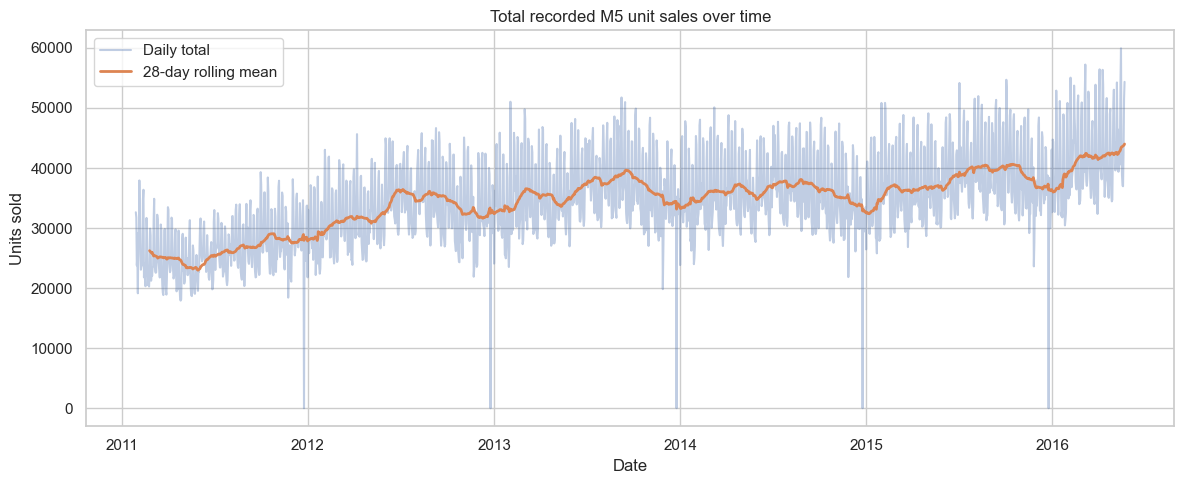

In [11]:
daily_total_sales = pd.Series(
    sales_values.sum(axis=0),
    index=evaluation_day_columns,
    name="total_units",
)
daily_sales_plot = calendar.set_index("d").loc[evaluation_day_columns, ["date"]].copy()
daily_sales_plot["total_units"] = daily_total_sales.values
daily_sales_plot["28_day_rolling_mean"] = daily_sales_plot["total_units"].rolling(28).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_sales_plot["date"], daily_sales_plot["total_units"], alpha=0.35, label="Daily total")
ax.plot(
    daily_sales_plot["date"],
    daily_sales_plot["28_day_rolling_mean"],
    linewidth=2,
    label="28-day rolling mean",
)
ax.set(title="Total recorded M5 unit sales over time", xlabel="Date", ylabel="Units sold")
ax.legend()
plt.tight_layout()
plt.show()

### Aggregate-sales inference

The plot shows that total recorded sales are not constant across the full history. Both short-term fluctuations and broader level changes are visible. This supports using chronological evaluation rather than randomly mixing dates. Because aggregation can hide very different product-level behavior, later EDA must examine the selected product-store series individually before forecasting methods are chosen.

## 9. Initial EDA: zero-sales variation across series

The overall zero percentage does not show whether every series is equally sparse. The distribution below calculates a separate zero-sales proportion for each product-store series. This helps motivate a documented sample containing different demand patterns.

,zero_sales_share
count,30490.000000
mean,0.679978
std,0.223406
min,0.001546
25%,0.534776
50%,0.733127
75%,0.865018
90%,0.928387
max,0.993818


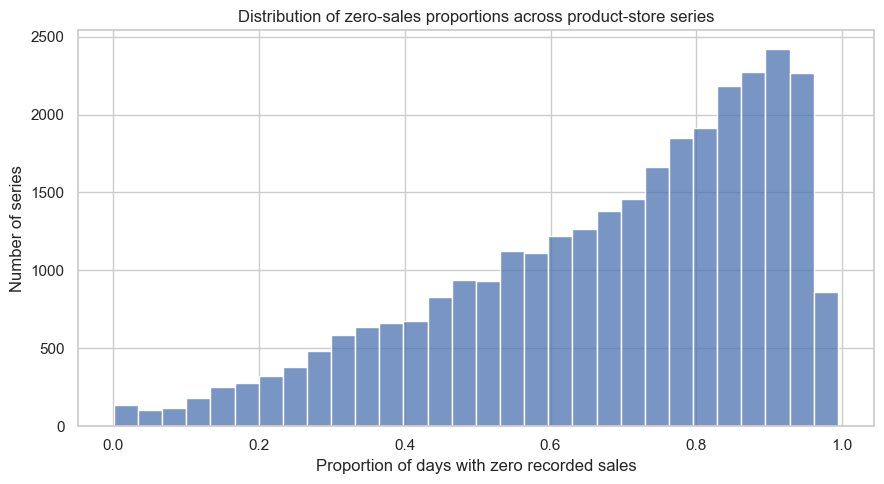

In [12]:
zero_share_by_series = (sales_values == 0).mean(axis=1)

display(
    pd.Series(zero_share_by_series, name="zero_sales_share")
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9])
    .to_frame()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(zero_share_by_series, bins=30, ax=ax)
ax.set(
    title="Distribution of zero-sales proportions across product-store series",
    xlabel="Proportion of days with zero recorded sales",
    ylabel="Number of series",
)
plt.tight_layout()
plt.show()

### Zero-sales inference

The zero-sales proportion varies substantially across product-store series rather than being identical for all products. Statistically, this indicates heterogeneous intermittency. Practically, a fixed safety-stock buffer may not adapt well to both frequently selling and highly sparse series. The next stage should calculate documented series-level features and use only pre-test information to select representative stable, variable, seasonal, and intermittent examples.

## 10. Audit conclusion and next steps

### Findings

- All five required files are present and readable.
- The evaluation data contain 30,490 unique product-store series and 1,941 daily sales columns.
- No duplicate series IDs or negative sales values were found.
- Approximately 68% of series-day sales observations are zero, showing that intermittency is central to this project.
- Calendar dates are unique, complete, and consecutive.
- Price keys are unique and existing prices are positive and non-missing.
- The identifier domains required for the planned joins are present.

### Limitations

These checks establish structural validity, not complete business validity. The data do not reveal actual inventory availability or unmet demand. Price match rates have not yet been measured at the daily long-form level. Initial aggregate plots also cannot describe individual product behavior.

### Next steps

1. Reshape evaluation sales from wide to long format without changing totals.
2. Join calendar data and validate that the row count remains unchanged.
3. Join prices by store, item, and Walmart year-week and measure unmatched rows.
4. Define a final chronological test period before selecting series or tuning models.
5. Calculate series-level features using pre-test data and apply a reproducible sampling rule.